In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Hotel_Reviews.csv")

In [3]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397.0,1403.0,Only the park outside of the hotel was beauti...,11.0,7.0,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0.0,1403.0,No real complaints the hotel was great great ...,105.0,7.0,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42.0,1403.0,Location was good and staff were ok It is cut...,21.0,9.0,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210.0,1403.0,Great location in nice surroundings the bar a...,26.0,1.0,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140.0,1403.0,Amazing location and building Romantic setting,8.0,3.0,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166904 entries, 0 to 166903
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               166904 non-null  object 
 1   Additional_Number_of_Scoring                166904 non-null  int64  
 2   Review_Date                                 166904 non-null  object 
 3   Average_Score                               166904 non-null  float64
 4   Hotel_Name                                  166904 non-null  object 
 5   Reviewer_Nationality                        166904 non-null  object 
 6   Negative_Review                             166904 non-null  object 
 7   Review_Total_Negative_Word_Counts           166903 non-null  float64
 8   Total_Number_of_Reviews                     166903 non-null  float64
 9   Positive_Review                             166903 non-null  object 
 

In [5]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [6]:
df["Review"] = df["Positive_Review"] + " " + df["Negative_Review"]

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return "" # Handle non-string types, especially NaN which is a float
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

print(df["Clean_Review"].head())

0    park outside hotel beautiful angry made post a...
1    real complaint hotel great great location surr...
2    location good staff ok cute hotel breakfast ra...
3    great location nice surroundings bar restauran...
4    amazing location building romantic setting boo...
Name: Clean_Review, dtype: object


In [9]:
pip install textblob

In [10]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

print(df["Sentiment"].value_counts())

Sentiment
Positive    133646
Negative     25084
Neutral       8174
Name: count, dtype: int64


In [11]:
issues = [
    "room",
    "clean",
    "staff",
    "food",
    "wifi",
    "service",
    "bathroom",
    "location"
]

for issue in issues:
    count = df["Clean_Review"].str.contains(issue).sum()
    print(issue, ":", count)

room : 93192
clean : 27325
staff : 71214
food : 8287
wifi : 5431
service : 14734
bathroom : 14492
location : 63288


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(df["Clean_Review"])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

result = pd.DataFrame({
    "Word": words,
    "Frequency": counts
})

print(result.sort_values("Frequency", ascending=False))

           Word  Frequency
14         room     133741
17        staff      77889
11     location      65510
10        hotel      62501
2     breakfast      44040
7          good      40640
12     negative      40634
8         great      36311
1           bed      34415
6      friendly      29415
9       helpful      25486
16        small      24578
13         nice      23160
3         clean      23081
4   comfortable      21319
5     excellent      20374
18         stay      17075
19        would      16742
15      service      16194
0      bathroom      15713


In [13]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    133646
Negative     25084
Neutral       8174
Name: count, dtype: int64


In [14]:
print("Average Rating:", df["Reviewer_Score"].mean())

Average Rating: 8.33336428943758


In [15]:
positive = (df["Sentiment"] == "Positive").sum()
negative = (df["Sentiment"] == "Negative").sum()
neutral = (df["Sentiment"] == "Neutral").sum()

total = len(df)

print("Positive %:", positive * 100 / total)
print("Negative %:", negative * 100 / total)
print("Neutral %:", neutral * 100 / total)

Positive %: 80.07357522887408
Negative %: 15.028998705842879
Neutral %: 4.897426065283037


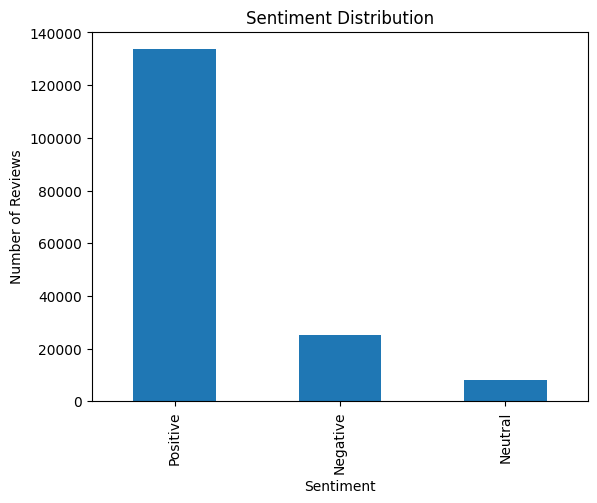

In [16]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

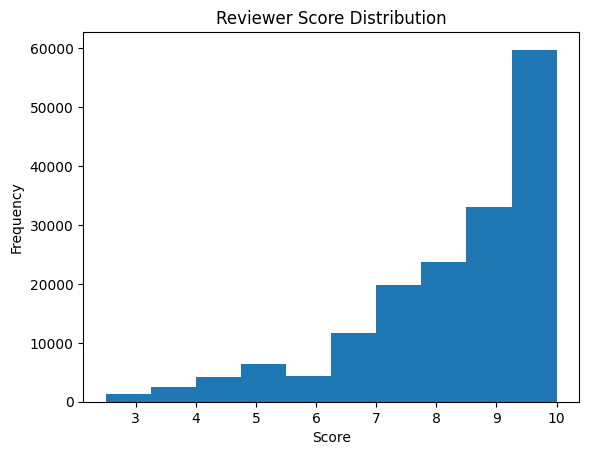

In [17]:
plt.hist(df["Reviewer_Score"], bins=10)

plt.title("Reviewer Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

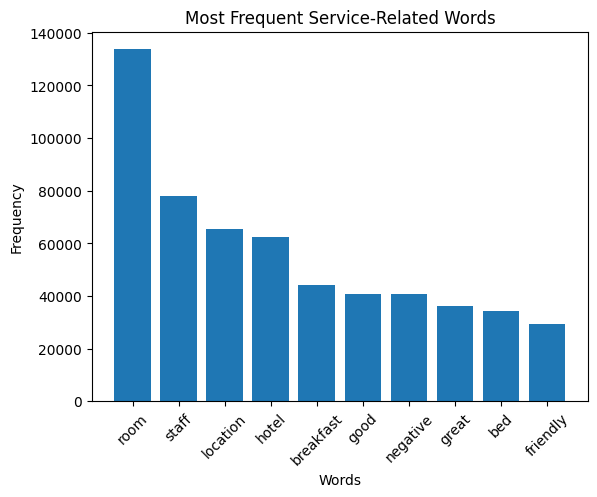

In [18]:
top10 = result.sort_values("Frequency", ascending=False).head(10)

plt.bar(top10["Word"], top10["Frequency"])

plt.xticks(rotation=45)
plt.title("Most Frequent Service-Related Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()